# Classification Metrics Overview

When evaluating a classification model, accuracy alone is often not enough. The following metrics help understand *how* a model makes errors — and which types of errors matter most.

---

## Accuracy
**Definition:**  
The proportion of all predictions that were correct.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

**Meaning:**  
“How often is the model right overall?”

**Use when:**  
- classes are balanced  
- all errors have similar cost  

**Warning:**  
Accuracy can be misleading with imbalanced datasets (e.g., rare diseases or fraud detection).  
A model can achieve 99% accuracy by always predicting the majority class.

---

## Precision
**Definition:**  
Of all predicted positives, how many are actually positive?

Precision = TP / (TP + FP)

**Meaning:**  
“How much can we trust a positive prediction?”

**Use when:**  
- false positives are costly  
- examples:
  - email spam filtering  
  - fraud detection  

**High precision:**  
Few False Positives (FP).

---

## Recall (Sensitivity / True Positive Rate)
**Definition:**  
Of all actual positives, how many did the model correctly identify?

Recall = TP / (TP + FN)

**Meaning:**  
“How many real positives did the model catch?”

**Use when:**  
- missing a positive case is dangerous  
- examples:
  - medical diagnoses  
  - safety-critical detection tasks  

**High recall:**  
Few False Negatives (FN).

---

## F1 Score
**Definition:**  
The harmonic mean of Precision and Recall.

F1 = 2 * (Precision * Recall) / (Precision + Recall)

**Meaning:**  
A single metric that balances Precision and Recall.

**Use when:**  
- classes are imbalanced  
- both false positives and false negatives matter  
- you want one metric to compare models

---

# Why These Metrics Matter

**Accuracy** – general correctness  
  Useful only with balanced data and equal error costs.

**Precision** – reliability of positive predictions  
  Important when false positives are expensive.

**Recall** – ability to detect actual positives  
  Important when false negatives are dangerous.

**F1 Score** – combined view of Precision and Recall  
  Good for imbalanced datasets and varied error costs.




## Good Visualization:
![alt text](image.png)

## Exercise:

## Calculate the Accuracy, Precision, Recall & F1 Value:
<img src="dogs.png" alt="alt text" width="80%">

## KFold  

The Idea:

*   K-Fold Cross-Validation is a method to evaluate a machine-learning model more 

*   More reliable than with a single train/test split.


Instead of training once, we:

Split the dataset into K equal parts ("folds")

*   Train the model K times
*   Each time using a different fold as the test set
*   And the remaining K–1 folds as the training set
*   Average the results

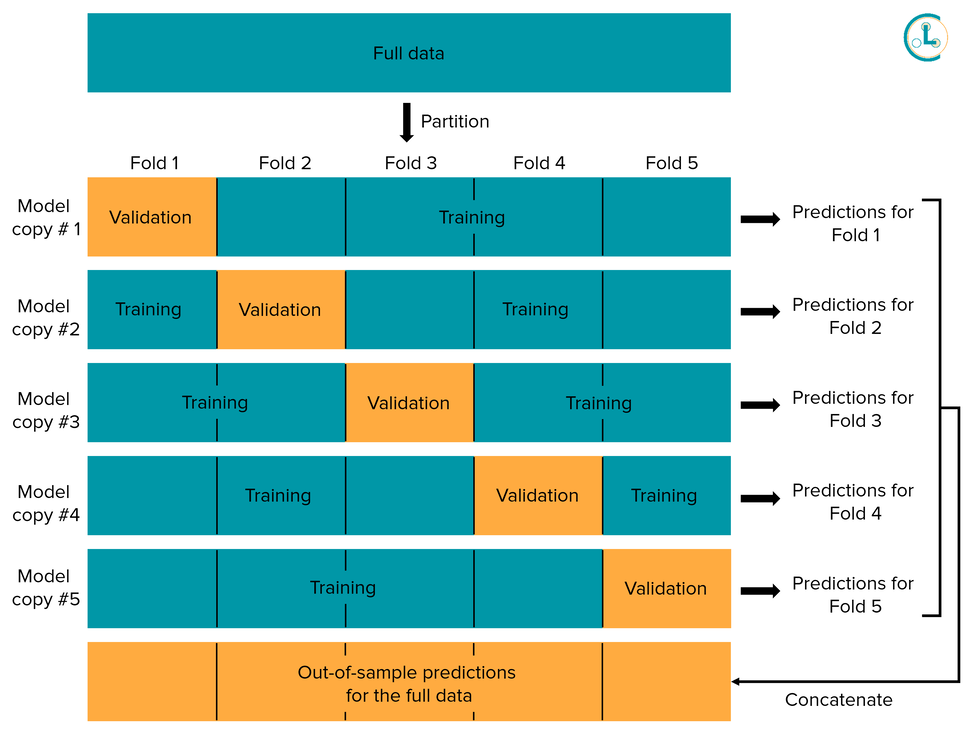

## Regular Training/Test Split:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme()


digits = load_digits()
X = pd.DataFrame(digits.data)
y = pd.Series(digits.target)

X.shape, y.shape

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for ax, img, label in zip(axes, digits.images[:5], digits.target[:5]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Single Train/Test Accuracy:", accuracy_score(y_test, y_pred))



## Enhanced version with KFold: 

In [ ]:
from sklearn.model_selection import KFold

skf = KFold(n_splits=10, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=200)

fold_accuracies = []
all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    fold_accuracies.append(acc)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print(f"Fold {fold} Accuracy: {acc:.4f}")

print("\nMean CV Accuracy:", np.mean(fold_accuracies))
print("Std of CV Accuracy:", np.std(fold_accuracies))

## Exercise to implement: 

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --------------------------------
# 1) Create synthetic regression dataset
# --------------------------------
X, y = datasets.make_regression(
    n_samples=100,
    n_features=5,
    n_informative=5,
    noise=10,
    random_state=0
)

# --------------------------------
# 2) K-Fold Cross Validation (TO IMPLEMENT)
# --------------------------------
kf = ...

model = LinearRegression()

fold_scores = []

 #TODO: iterate through the folds
 for train_idx, test_idx in kf.split(X):
      #TODO: get X_train, X_test, y_train, y_test
      X_train =
      X_test =
      y_train =
      y_test =

     # TODO: train the model
      model.fit(...)

     # TODO: make predictions
      preds = model.predict(...)

     # TODO: compute R² score and append to fold_scores
      score = r2_score(...)
      fold_scores.append(score)

 print("K-Fold R² scores:", fold_scores)
 print("Mean R²:", np.mean(fold_scores))

# --------------------------------
# 3) Single Train/Test Split (for comparison)
# --------------------------------

#TODO: Perform a standard train/test split
X_train, X_test, y_train, y_test = train_test_split(...)

#TODO: train model on this single split
single_model = LinearRegression()
single_model.fit(...)

#TODO: predict and compute R²
y_pred = single_model.predict(...)
single_r2 = r2_score(...)

print("\nSingle split R²:", single_r2)

#--------------------------------
#4) Comparison (once both are filled)
#--------------------------------

print("\n=== Comparison ===")
print("Mean K-Fold R²:", np.mean(fold_scores))
print("Single Split R²:", single_r2)

